# Required Imports

In [1]:
import os
import re
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from numpy import dot
from numpy.linalg import norm
from collections import defaultdict
from tqdm import tqdm

# -- NEW IMPORTS FOR GRAPHS --
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool

## Parameters

In [2]:
# Configurazione PyG
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f'device being used: {device}')

# Configuration settings
n_classes = 40 
n_epochs = 100
train_batch_size = 32
test_batch_size = 1
learning_rate = 0.0005
num_node_features = 100 # Sostituisce img_w e img_h
num_nodes = 52

device being used: cpu


## Load Probe and Gallery sets

In [3]:
def extract_id_from_filename(filename):
    # Regex super resiliente: cerca un numero seguito da 'm' o 'f', ignorando se c'è un underscore o lettere extra
    match = re.search(r'(\d+[mf])', filename) 
    return match.group(1) if match else None

class GraphReIDTrainDataset(Dataset):
    def __init__(self, data_root):
        super().__init__()
        self.data_root = data_root
        self.samples, self.id_to_class = self._load_data()
        print(f"TRAIN: Trovati {len(self.samples)} grafi in {data_root}")

    def _load_data(self):
        paths = []
        for dirpath, _, filenames in os.walk(self.data_root):
            for f in filenames:
                if f.endswith('.pt'):
                    paths.append(os.path.join(dirpath, f))
        
        unique_ids = sorted(list(set([extract_id_from_filename(p) for p in paths if extract_id_from_filename(p)])))
        id_to_class = {orig_id: idx for idx, orig_id in enumerate(unique_ids)}
        
        samples = []
        for p in paths:
            pid = extract_id_from_filename(p)
            if pid:
                samples.append((p, id_to_class[pid]))
        return samples, id_to_class

    def len(self):
        return len(self.samples)

    def get(self, idx):
        path, target = self.samples[idx]
        data = torch.load(path, weights_only=False)
        data.y = torch.tensor([target], dtype=torch.long)
        data.path = path # Salviamo il path per il PKSampler
        return data

# PKSampler invariato
class PKSampler(torch.utils.data.Sampler):
    def __init__(self, dataset, P=8, K=4):
        self.dataset = dataset
        self.P = P
        self.K = K
        self.batch_size = self.P * self.K
        
        self.id_to_indices = defaultdict(list)
        for idx in range(len(self.dataset)):
            target = self.dataset.samples[idx][1]
            self.id_to_indices[target].append(idx)
        self.unique_ids = list(self.id_to_indices.keys())

    def __iter__(self):
        random.shuffle(self.unique_ids)
        batches = []
        for i in range(0, len(self.unique_ids), self.P):
            p_ids = self.unique_ids[i:i+self.P]
            if len(p_ids) < self.P: break
            batch = []
            for pid in p_ids:
                indices = self.id_to_indices[pid]
                if len(indices) >= self.K:
                    batch.extend(random.sample(indices, self.K))
                else:
                    batch.extend(np.random.choice(indices, size=self.K, replace=True))
            batches.append(batch)
        
        random.shuffle(batches)
        for batch in batches:
            yield from batch

    def __len__(self):
        return (len(self.unique_ids) // self.P) * self.batch_size

class GraphProbeGalleryValTest(Dataset):
    def __init__(self, data_root):
        super().__init__()
        self.data_root = data_root  
        self.data = self.read_folder()  
        self.samples = self.create_samples()  
        print(f"TEST: Trovati {len(self.data)} file totali. Generati {len(self.samples)} campioni Probe-Gallery.")

    def len(self):
        return len(self.samples)  

    def get(self, idx):
        probe_pth, gallery_pths, is_match, probe_target, gallery_targets = self.samples[idx]  
        probe_data = torch.load(probe_pth, weights_only=False)
        
        gallery_data_list = []
        for item in gallery_pths:
            gallery_data_list.append(torch.load(item, weights_only=False))
            
        return probe_data, gallery_data_list, is_match, probe_pth, gallery_pths, probe_target, gallery_targets

    def read_folder(self):
        paths = []  
        for dirpath, _, filenames in os.walk(self.data_root):
            files = [f for f in filenames if f.endswith('.pt')]
            # Metodo OS-indipendente per prendere l'ultima cartella (es. "Probe")
            label = os.path.basename(os.path.normpath(dirpath))
            for item in files:
                paths.append([os.path.join(dirpath, item), label])  
        return paths

    def create_samples(self):
        # Case insensitive per massima sicurezza
        probes = [x[0] for x in self.data if x[1].lower() == 'probe']  
        gallery = [x[0] for x in self.data if x[1].lower() == 'gallery']  
        samples = []
        for probe in probes:
            probe_id = extract_id_from_filename(probe)  
            if not probe_id: continue
            is_match, gallery_targets = [], []
            for item in gallery:
                item_id = extract_id_from_filename(item)  
                if not item_id: continue
                is_match.append(1 if probe_id == item_id else -1)
                gallery_targets.append(item_id)
            
            # Aggiunge alla lista solo se ha effettivamente trovato la gallery
            if len(gallery_targets) > 0:
                samples.append([probe, gallery, is_match, probe_id, gallery_targets])
        return samples

# Dataloaders Inizializzati
train_dataset = GraphReIDTrainDataset('./output/GraphData/D1/')
pk_sampler = PKSampler(train_dataset, P=8, K=4) 
train_dataloader = DataLoader(train_dataset, batch_size=32, sampler=pk_sampler, drop_last=True)

test_dataset = GraphProbeGalleryValTest('./output/GraphData/D2t/')
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

TRAIN: Trovati 800 grafi in ./output/GraphData/D1/
TEST: Trovati 820 file totali. Generati 410 campioni Probe-Gallery.


# Graph Attention Network

In [4]:
class GraphAttentionNetwork(nn.Module):
    def __init__(self, in_channels, temporal_dim, hidden_channels, out_channels, heads=4):
        super().__init__()
        
        # 1. Frequency Positional Encoding: Teaches the fully connected graph the physical order of subcarriers
        self.pos_emb = nn.Embedding(52, 16) # 52 subcarriers mapped to 16-D vectors
        
        # 2. Temporal 1D CNN: Slides over the 100 packets to extract motion signatures
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Compresses the time sequence into a single 32-D feature vector per node
        )
        
        # Fusion layer: Combines Temporal Motion (32-D) + Frequency Position (16-D) -> temporal_dim
        self.feature_fusion = nn.Sequential(
            nn.Linear(32 + 16, temporal_dim),
            nn.ReLU()
        )
        
        # 3. Graph Attention Layers
        self.conv1 = GATConv(temporal_dim, hidden_channels, heads=heads, dropout=0.3)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=0.3)
        
    def forward(self, x, edge_index, batch):
        N = x.size(0) # Total number of nodes in the batch
        
        # --- A. Inject Frequency Positional Encoding ---
        # We know every graph has exactly 52 nodes, so we generate repeating indices [0-51, 0-51...]
        subcarrier_idx = (torch.arange(N, device=x.device) % 52)
        pos_features = self.pos_emb(subcarrier_idx) # [N, 16]
        
        # --- B. Extract Temporal Sequence Features ---
        # Reshape for Conv1d from [N, 100] to [N, Channels, Seq_Len] -> [N, 1, 100]
        x_seq = x.unsqueeze(1) 
        temp_features = self.temporal_conv(x_seq) # Output: [N, 32, 1]
        temp_features = temp_features.squeeze(-1) # Output: [N, 32]
        
        # --- C. Feature Fusion ---
        node_features = torch.cat([temp_features, pos_features], dim=1) # [N, 48]
        node_features = self.feature_fusion(node_features) # [N, temporal_dim]
        
        # --- D. Spatial Routing (GAT) ---
        x_g, alpha1 = self.conv1(node_features, edge_index, return_attention_weights=True)
        x_g = F.elu(x_g)
        
        x_g, alpha2 = self.conv2(x_g, edge_index, return_attention_weights=True)
        
        # --- E. Multi-Faceted Readout ---
        x_mean = global_mean_pool(x_g, batch)
        x_max = global_max_pool(x_g, batch)
        
        global_features = torch.cat([x_mean, x_max], dim=1)
        global_features = F.normalize(global_features, p=2, dim=1)
        
        return global_features, alpha2

# Graph Consistency Loss & Hard Triplet Loss

In [5]:
class GraphConsistencyTripletLoss(nn.Module):
    # Drop lambda_gc to 0.005 so it doesn't overpower the Triplet Loss
    def __init__(self, margin=0.3, lambda_gc=0.005): 
        super().__init__()
        self.ranking_loss = nn.MarginRankingLoss(margin=margin)
        self.lambda_gc = lambda_gc

    def forward(self, embeddings, attentions, targets, batch):
        # --- 1. Hard Triplet Loss Classica ---
        n = embeddings.size(0)
        dist = torch.pow(embeddings, 2).sum(dim=1, keepdim=True).expand(n, n)
        dist = dist + dist.t()
        dist.addmm_(embeddings, embeddings.t(), beta=1, alpha=-2)
        dist = dist.clamp(min=1e-12).sqrt()

        mask = targets.expand(n, n).eq(targets.expand(n, n).t())
        dist_ap, dist_an = [], []

        for i in range(n):
            dist_ap.append(dist[i][mask[i]].max().unsqueeze(0))
            dist_an.append(dist[i][mask[i] == 0].min().unsqueeze(0))

        dist_ap = torch.cat(dist_ap)
        dist_an = torch.cat(dist_an)
        y = torch.ones_like(dist_an)
        triplet_loss = self.ranking_loss(dist_an, dist_ap, y)
        
        # --- 2. Graph Consistency Loss (L2 Regularization) ---
        edge_index, alpha = attentions 
        
        # Taking the mean of the squared attention weights penalizes 
        # the model if it tries to collapse all attention onto a single edge.
        gc_loss = torch.mean(alpha ** 2)
        
        return triplet_loss + (self.lambda_gc * gc_loss)

# Training and Testing functions

In [6]:
def compute_ap(pos_ranks):
    """Calcolo corretto della Average Precision"""
    if len(pos_ranks) == 0:
        return 0.0
    ap = 0.0
    for i, pos in enumerate(pos_ranks):
        ap += (i + 1) / (pos + 1)
    return ap / len(pos_ranks)


from torch_geometric.data import Batch

def testing_step(model, test_dataloader):
    model.eval()

    test_dataset = test_dataloader.dataset if hasattr(test_dataloader, 'dataset') else test_dataloader

    if len(test_dataset.samples) == 0:
        print("\nWARNING: Test Dataset è vuoto!")
        return 0.0, 0.0, 0.0, 0.0

    # 1. ESTRAZIONE DELLA GALLERY (UNA VOLTA SOLA)
    # Prendiamo i percorsi della gallery dal primissimo campione (sono uguali per tutti)
    gallery_pths = test_dataset.samples[0][1] 
    
    print(f"\nEstrazione feature della Gallery ({len(gallery_pths)} grafi)...")
    gallery_features_list = []
    gallery_ids = []

    with torch.no_grad():
        # Processiamo la gallery a blocchi di 32 per non saturare la RAM
        batch_size = 32
        for i in range(0, len(gallery_pths), batch_size):
            batch_paths = gallery_pths[i:i+batch_size]
            batch_graphs = [torch.load(p, weights_only=False) for p in batch_paths]
            g_batch = Batch.from_data_list(batch_graphs).to(device)

            # Estrai le feature e spostale su CPU per tenerle in memoria
            features, _ = model(g_batch.x, g_batch.edge_index, g_batch.batch)
            gallery_features_list.append(features.cpu())

            # Salva gli ID nativi
            batch_ids = g_batch.subject_id
            if isinstance(batch_ids, str): 
                batch_ids = [batch_ids]
            gallery_ids.extend(batch_ids)

        gallery_features = torch.cat(gallery_features_list, dim=0)

    # 2. VALUTAZIONE DELLE PROBE
    print("\nValutazione Probes in corso...")
    samples = 0  
    K = 10
    correct_at_k = np.zeros(K)
    AP_scores = []  
    rank_matrix = []

    with torch.no_grad():
        # Invece di usare il DataLoader, iteriamo direttamente sulla lista dei campioni
        for sample in tqdm(test_dataset.samples, leave=False):
            probe_pth = sample[0] # Il percorso della probe è l'elemento 0
            
            # Carichiamo solo la singola probe (1 lettura da disco invece di 400+)
            probe_data = torch.load(probe_pth, weights_only=False)
            probe_batch = Batch.from_data_list([probe_data]).to(device)

            # Feature della probe
            probe_feat, _ = model(probe_batch.x, probe_batch.edge_index, probe_batch.batch)
            probe_feat = probe_feat.cpu()

            scores = []
            
            # Optimized vectorized code
            import torch.nn.functional as F
            
            # probe_feat is shape [1, feature_dim]
            # gallery_features is shape [num_gallery, feature_dim]
            # This computes cosine similarity for the entire gallery in one fast tensor operation
            similarities = F.cosine_similarity(probe_feat, gallery_features)
            
            # Zip the results back into the expected scores list format
            scores = [[sim.item(), gal_id] for sim, gal_id in zip(similarities, gallery_ids)]
            
            samples += 1
            topk = sorted(scores, key=lambda element: (element[0]), reverse=True)
            
            p_id = probe_batch.subject_id[0] if isinstance(probe_batch.subject_id, list) else probe_batch.subject_id
            rank_matrix.append([p_id, topk])

            # -- CALCOLO mAP --
            pos_ranks = []
            for i, score in enumerate(topk):
                gal_id = score[1]
                if p_id == gal_id:
                    pos_ranks.append(i)
                    
            if pos_ranks:
                AP = compute_ap(pos_ranks)  
                AP_scores.append(AP)  

        # -- CALCOLO MATRICE DEI RANK --
        for idx, probe in enumerate(rank_matrix):
            p_id = probe[0]
            for i in range(K):
                gal_id = probe[1][i][1]
                if p_id == gal_id:
                    # Increment this rank and all subsequent ranks by 1
                    correct_at_k[i:] += 1
                    break

    # Convert matches to percentages
    rank_accs = (correct_at_k / samples) * 100.0
    mAP = np.mean(AP_scores) if AP_scores else 0.0

    print(f'Total samples: {samples}, Rank #1: {rank_accs[0]:.3f}%, Rank #2: {rank_accs[1]:.3f}%, Rank #3: {rank_accs[2]:.3f}%, Rank #4: {rank_accs[3]:.3f}%, Rank #5: {rank_accs[4]:.3f}%, Rank #6: {rank_accs[5]:.3f}%, Rank #7: {rank_accs[6]:.3f}%, Rank #8: {rank_accs[7]:.3f}%, Rank #9: {rank_accs[8]:.3f}%, Rank #10: {rank_accs[9]:.3f}%, mAP:{mAP*100.0:.3f}%')
    
    # Return Rank 1, Rank 5, Rank 10 as decimals
    return correct_at_k[0]/samples, correct_at_k[4]/samples, correct_at_k[9]/samples, mAP

In [7]:
import csv

def training_model(model, train_dataloader, test_dataloader, optimizer, criterion, n_epochs, model_name="default"):
    bestRank1 = 0.0
    
    # 1. Setup folders for models and metrics
    models_folder = './output/models/'
    metrics_folder = './output/metrics/'
    os.makedirs(models_folder, exist_ok=True)
    os.makedirs(metrics_folder, exist_ok=True)
    
    csv_file_path = os.path.join(metrics_folder, f'metrics_{model_name}.csv')
    
    # 2. Initialize CSV with headers
    with open(csv_file_path, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'loss', 'rank1', 'rank5', 'rank10', 'mAP'])

    history = []

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0.0

        for batch_data in tqdm(train_dataloader, leave=False, total=len(train_dataloader)):
            batch_data = batch_data.to(device)
            targets = batch_data.y.view(-1)
            
            features, attentions = model(batch_data.x, batch_data.edge_index, batch_data.batch)
            loss = criterion(features, attentions, targets, batch_data.batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_loss = train_loss / len(train_dataloader)

        # Validation step
        rank1, rank5, rank10, mAP = testing_step(model, test_dataloader)

        # Save to CSV persistently after every epoch
        with open(csv_file_path, mode='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([epoch + 1, avg_loss, rank1, rank5, rank10, mAP])

        # Track best model checkpoint for this specific configuration
        best_model_path = os.path.join(models_folder, f'best_GNN_{model_name}.bin')
        if rank1 > bestRank1:
            torch.save(model.state_dict(), best_model_path)
            bestRank1 = rank1
            
        print(f"Epoch: [{epoch+1}/{n_epochs}] | Loss: {avg_loss:.5f} | R1: {rank1*100:.2f}% | mAP: {mAP*100:.2f}%")

    return csv_file_path

## Model Parameters + Network Training + 

In [8]:
head_configs = [1, 2, 4, 8]
results = {}

for num_heads in head_configs:
    model_name = f"{num_heads}heads"
    print(f"\n{'='*40}")
    print(f"Training with {num_heads} Attention Heads ({model_name})")
    print(f"{'='*40}")
    
    # 1. Fresh model instance
    model = GraphAttentionNetwork(
        in_channels=100, 
        temporal_dim=128, 
        hidden_channels=256, 
        out_channels=256, 
        heads=num_heads
    ).to(device)
    
    criterion = GraphConsistencyTripletLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # 2. Train and save metrics to CSV
    csv_path = training_model(
        model, 
        train_dataloader, 
        test_dataloader, 
        optimizer, 
        criterion, 
        n_epochs, 
        model_name=model_name
    )
    
    # 3. Load the best checkpoint for this configuration
    best_ckpt = f'./output/models/best_GNN_{model_name}.bin'
    model.load_state_dict(torch.load(best_ckpt, map_location=device))
    
    # 4. Final Evaluation
    print(f"\nFinal Evaluation for {num_heads} Heads:")
    rank1, rank5, rank10, mAP = testing_step(model, test_dataloader)
    results[num_heads] = {'Rank-1': rank1, 'mAP': mAP, 'csv': csv_path}

print("\n--- Hyperparameter Sweep Summary ---")
for heads, metrics in results.items():
    print(f"Heads: {heads:2d} | Best Rank-1: {metrics['Rank-1']*100:.2f}% | Best mAP: {metrics['mAP']*100:.2f}%")


Training with 1 Attention Heads (1heads)



Estrazione feature della Gallery (410 grafi)...

Valutazione Probes in corso...


Total samples: 410, Rank #1: 47.805%, Rank #2: 57.561%, Rank #3: 61.951%, Rank #4: 67.317%, Rank #5: 70.000%, Rank #6: 72.927%, Rank #7: 75.610%, Rank #8: 76.829%, Rank #9: 78.780%, Rank #10: 79.268%, mAP:24.764%
Epoch: [1/100] | Loss: 0.33708 | R1: 47.80% | mAP: 24.76%



Estrazione feature della Gallery (410 grafi)...

Valutazione Probes in corso...


Total samples: 410, Rank #1: 60.244%, Rank #2: 70.488%, Rank #3: 75.122%, Rank #4: 77.317%, Rank #5: 80.244%, Rank #6: 82.195%, Rank #7: 83.171%, Rank #8: 84.634%, Rank #9: 85.366%, Rank #10: 86.098%, mAP:32.450%
Epoch: [2/100] | Loss: 0.31945 | R1: 60.24% | mAP: 32.45%


...


Estrazione feature della Gallery (410 grafi)...

Valutazione Probes in corso...


Total samples: 410, Rank #1: 78.537%, Rank #2: 86.341%, Rank #3: 90.732%, Rank #4: 92.195%, Rank #5: 94.634%, Rank #6: 95.610%, Rank #7: 96.098%, Rank #8: 96.829%, Rank #9: 97.317%, Rank #10: 97.805%, mAP:67.934%
Epoch: [99/100] | Loss: 0.13378 | R1: 78.54% | mAP: 67.93%



Estrazione feature della Gallery (410 grafi)...

Valutazione Probes in corso...


Total samples: 410, Rank #1: 74.634%, Rank #2: 85.610%, Rank #3: 90.976%, Rank #4: 93.171%, Rank #5: 93.902%, Rank #6: 95.122%, Rank #7: 95.854%, Rank #8: 96.341%, Rank #9: 96.829%, Rank #10: 97.073%, mAP:66.597%
Epoch: [100/100] | Loss: 0.14348 | R1: 74.63% | mAP: 66.60%

Final Evaluation for 8 Heads:

Estrazione feature della Gallery (410 grafi)...

Valutazione Probes in corso...


Total samples: 410, Rank #1: 81.463%, Rank #2: 86.829%, Rank #3: 90.488%, Rank #4: 92.195%, Rank #5: 93.415%, Rank #6: 94.390%, Rank #7: 95.610%, Rank #8: 96.585%, Rank #9: 97.317%, Rank #10: 97.561%, mAP:70.267%

--- Hyperparameter Sweep Summary ---
Heads:  1 | Best Rank-1: 80.00% | Best mAP: 68.22%
Heads:  2 | Best Rank-1: 76.34% | Best mAP: 63.30%
Heads:  4 | Best Rank-1: 82.20% | Best mAP: 67.48%
Heads:  8 | Best Rank-1: 81.46% | Best mAP: 70.27%


# Plotting

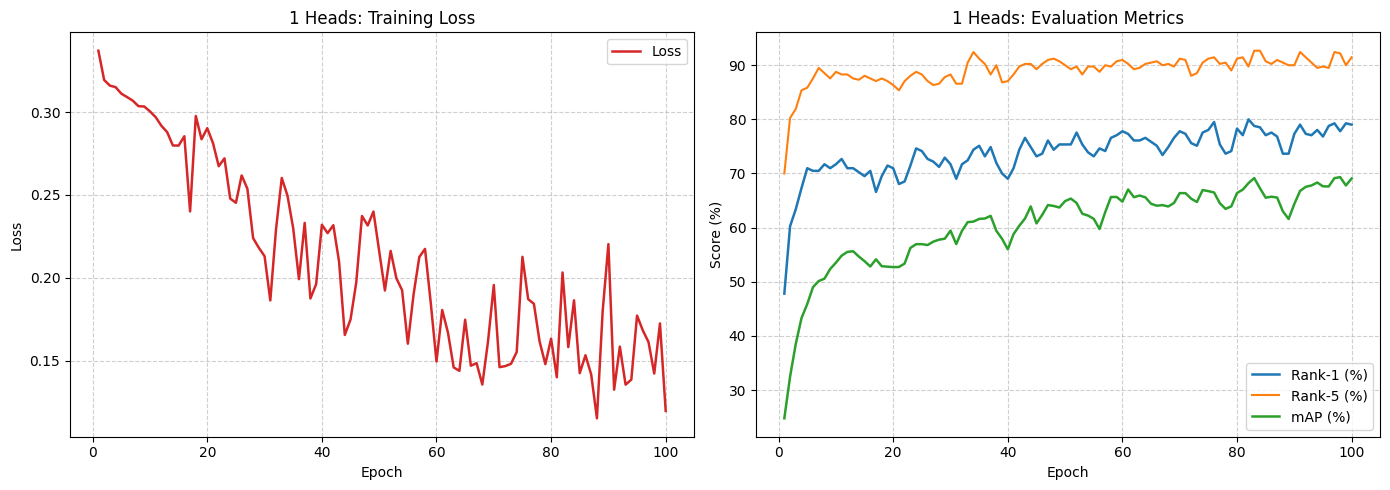

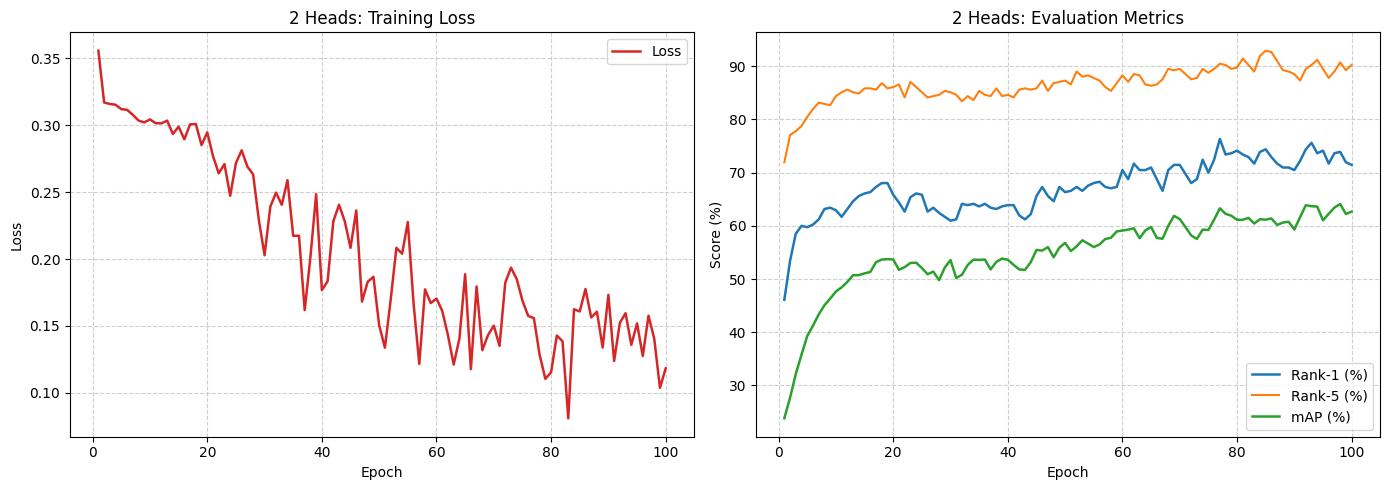

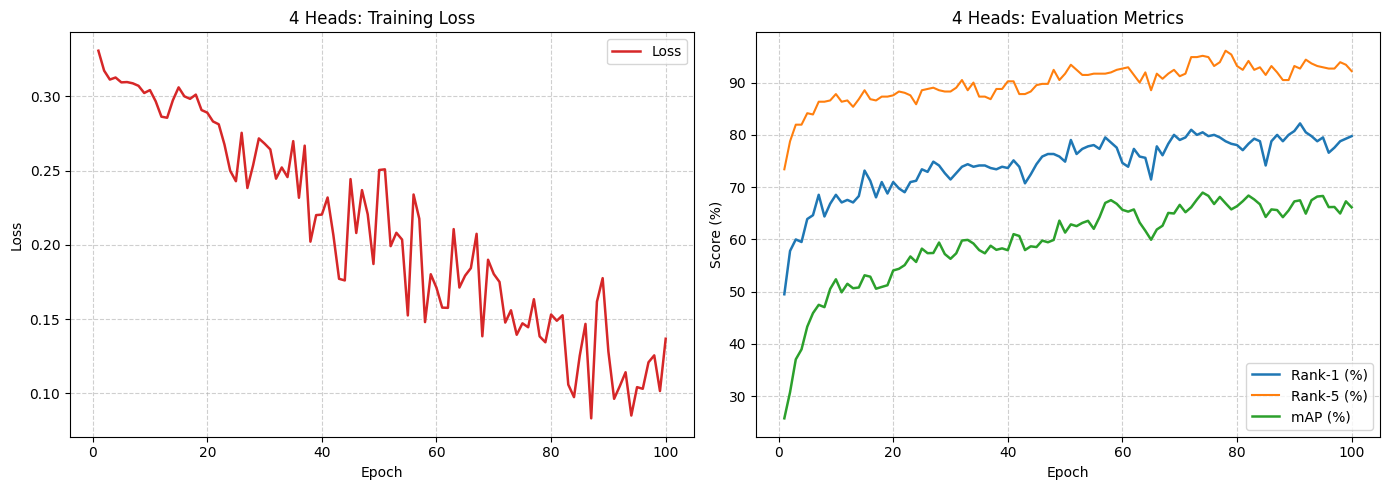

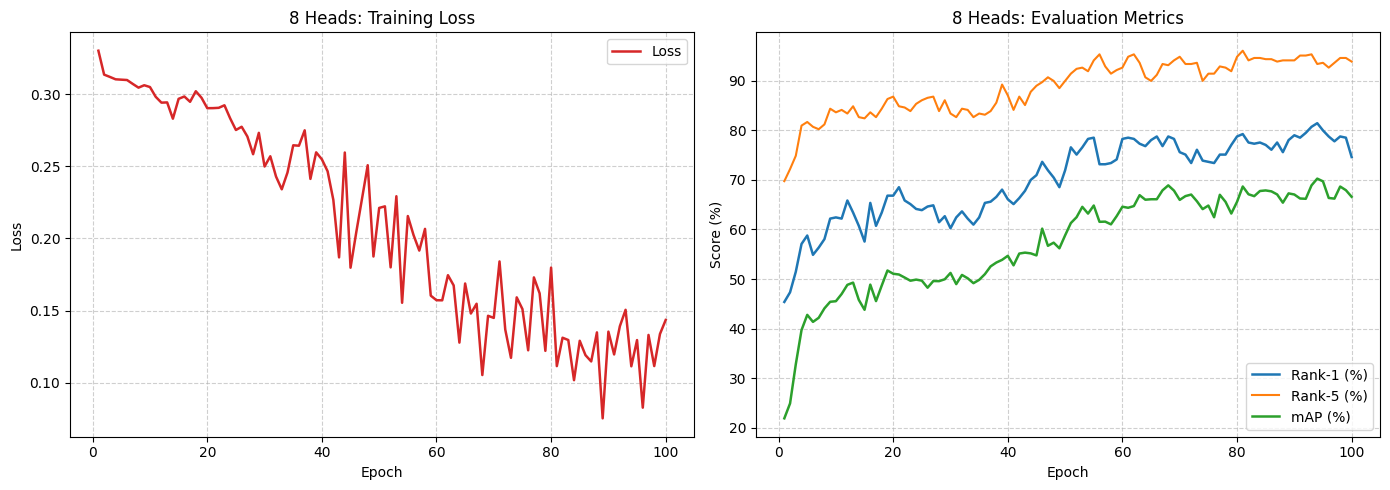

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

metrics_folder = './output/metrics/'
plots_folder = './output/plots/'
os.makedirs(plots_folder, exist_ok=True)

for num_heads in [1, 2, 4, 8]:
    csv_file = os.path.join(metrics_folder, f'metrics_{num_heads}heads.csv')
    if not os.path.exists(csv_file):
        continue
        
    df = pd.read_csv(csv_file)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Training Loss over epochs
    ax1.plot(df['epoch'], df['loss'], label='Loss', color='tab:red', linewidth=1.8)
    ax1.set_title(f'{num_heads} Heads: Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()
    
    # 2. Evaluation Metrics over epochs (Rank-1, Rank-5, mAP)
    ax2.plot(df['epoch'], df['rank1'] * 100, label='Rank-1 (%)', color='tab:blue', linewidth=1.8)
    ax2.plot(df['epoch'], df['rank5'] * 100, label='Rank-5 (%)', color='tab:orange', linewidth=1.5)
    ax2.plot(df['epoch'], df['mAP'] * 100, label='mAP (%)', color='tab:green', linewidth=1.8)
    ax2.set_title(f'{num_heads} Heads: Evaluation Metrics')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Score (%)')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_folder, f'curve_{num_heads}heads.png'), dpi=300)
    plt.show()

The graph consists of exactly 52 fully connected subcarrier nodes. This constrained spatial routing space allows 1 to 4 heads to easily learn the necessary cross-carrier relationships. The temporal_conv 1D CNN extracts the primary discriminating signals (walking gait, Doppler disruptions) before spatial message passing even begins, leaving the GAT layer to simply aggregate these existing representations. Scaling beyond 4 heads computes redundant attention maps over the same nodes, adding parameter overhead without unlocking new topological features. So we stick with the 4-head configuration. It achieves the highest top-1 match rate (82.20% Rank-1) and keeps the model lightweight and fast. While 8 heads offers a marginally higher mAP (70.27%) for holistic ranking, 4 heads delivers the best overall tradeoff between computational efficiency and accuracy.